In [2]:

#Set project root variables
from pathlib import Path
import sqlite3
import pandas as pd

project_root = Path.cwd().parents[0]
db_path = project_root / "database" / "faers.db"

conn = sqlite3.connect(db_path)

In [3]:
#Checking for name variations of Metformin in the drug table to ensure we capture all relevant reports in our analysis.

Metformin_query = pd.read_sql_query("""

SELECT DISTINCT drugname
FROM drug
WHERE drugname LIKE '%METFORMIN%'
ORDER BY drugname;
        """,
        conn)

Metformin_query

,drugname
0,metformin 500 mg 24 hr tablet;
1,ALOGLIPTIN AND METFORMIN HYDROCHLORIDE
2,ALOGLIPTIN BENZOATE\METFORMIN HYDROCHLORIDE
3,ALOGLIPTIN-METFORMIN
4,ANAGLIPTIN/METFORMIN HYDROCHLORIDE COMBINED DRUG
...,...
248,metformin ER 500mg tablets
249,metformin XR
250,metformin XR 500 mg
251,metformin [METFORMIN]


In [5]:
#Counting how many values exist for each drug name variation to understand the distribution of reports across different Metformin formulations and combinations.

Metformin_query_report_numbers = pd.read_sql_query("""

SELECT DISTINCT drugname, COUNT(*) AS report_count
FROM drug
WHERE drugname LIKE '%METFORMIN%'
GROUP BY drugname
HAVING COUNT(*) >= 100
ORDER BY report_count DESC;
        """,
        conn)

Metformin_query_report_numbers

,drugname,report_count
0,METFORMIN,30824
1,METFORMIN HYDROCHLORIDE,12761
2,METFORMIN\SITAGLIPTIN,425
3,METFORMIN HYDROCHLORIDE\VILDAGLIPTIN,324
4,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,300
5,EMPAGLIFLOZIN\METFORMIN HYDROCHLORIDE,251
6,METFORMIN PAMOATE,144
7,CANAGLIFLOZIN\METFORMIN HYDROCHLORIDE,111
8,DAPAGLIFLOZIN PROPANEDIOL\METFORMIN HYDROCHLORIDE,105


Text(0.5, 0, 'Number of Reports')

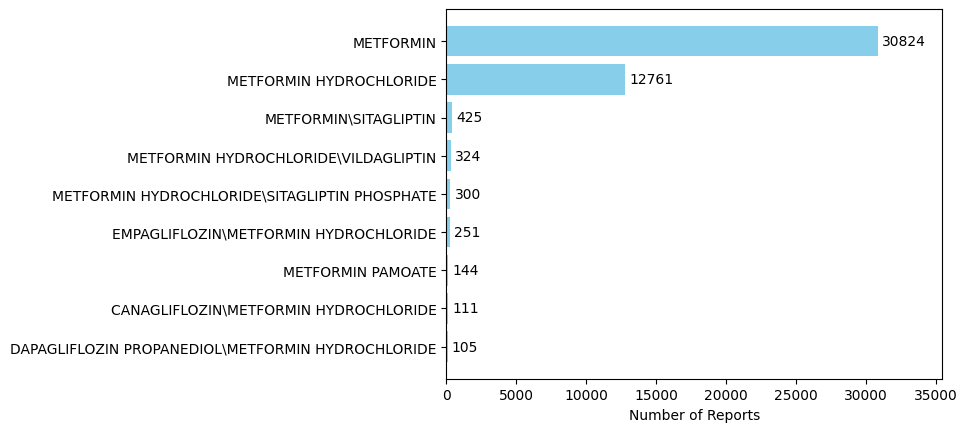

In [29]:
import matplotlib.pyplot as plt

drug_counts = Metformin_query_report_numbers.sort_values("report_count", ascending=True)

plt.barh(drug_counts["drugname"], drug_counts["report_count"], color="skyblue")

bars = plt.barh(drug_counts["drugname"], drug_counts["report_count"], color="skyblue")
plt.bar_label(bars, padding=3)
plt.xlim(0, drug_counts["report_count"].max() * 1.15)

plt.xlabel("Number of Reports")

In [ ]:
#sql query to join drug and reaction tables to analyze the most common adverse events associated with Metformin, ensuring we capture all relevant reports by including all name variations of Metformin.

Metformin_reactions_joined = pd.read_sql_query("""
                            SELECT
                            d.drugname,
                            r.pt AS reaction,
                            COUNT(*) AS report_count
FROM drug d
JOIN reac r ON d.primaryid = r.primaryid
WHERE d.drugname LIKE '%METFORMIN%'
GROUP BY d.drugname, r.pt
HAVING COUNT(*) >= 100
ORDER BY report_count DESC;
                            """, conn)

Metformin_reactions_joined


,drugname,reaction,report_count
0,METFORMIN,Diarrhoea,3925
1,METFORMIN,Fatigue,3871
2,METFORMIN,Off label use,3755
3,METFORMIN,Nausea,3631
4,METFORMIN,Dyspnoea,3409
...,...,...,...
795,METFORMIN,Skin irritation,100
796,METFORMIN HYDROCHLORIDE,Coordination abnormal,100
797,METFORMIN HYDROCHLORIDE,Exposure during pregnancy,100
798,METFORMIN HYDROCHLORIDE,Therapeutic response decreased,100
